# Mini-Projet : Classification Binaire par CNN
Diagnostic des Pathologies de la Pomme de Terre

Ce projet déploie un réseau de neurones convolutif (CNN) pour diagnostiquer automatiquement l'état de santé de plants de pomme de terre à partir d'images.

Objectif : Transformer un jeu de données de 1500 images pour réaliser une classification binaire stricte (Feuille Saine vs Feuille Malade).

Approche technique : Prétraitement des données (redimensionnement, normalisation), construction de l'architecture CNN, et optimisation des performances (ajout de Dropout, comparaison Adam/SGD, ajustement du taux d'apprentissage).

Résultats : Le modèle final démontre une bonne capacité de généralisation, atteignant un F1-Score de 83 % sur des données de test inédites.

Fiabilité : Intégration d'un système de pré-vérification autonome (modèle en cascade) qui rejette les images non pertinentes avant de lancer le diagnostic médical.

In [1]:
#importation des bibliotheque
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, f1_score

# ==============================================================================
# 0. CONFIGURATION DES CHEMINS
# ==============================================================================

In [2]:
# Si vous rencontrez encore une erreur "FileNotFoundError", remplacez './Potato' 
# par votre chemin absolu, par exemple : r"C:\Users\nzigu\...\UA3_IA\Potato"
base_dir = '.' 
binary_dataset_dir = os.path.join(base_dir, 'Binary_Potato_Dataset')

print("=== DÉMARRAGE DU PIPELINE ===")



=== DÉMARRAGE DU PIPELINE ===


# ==============================================================================
# 1. PRÉTRAITEMENT ET FUSION DES CLASSES (CLASSIFICATION BINAIRE)
# ==============================================================================


In [3]:
print("\n1. Réorganisation des dossiers...")
splits = ['Train', 'Valid', 'Test']

for split in splits:
    split_path = os.path.join(base_dir, split)
    if not os.path.exists(split_path): 
        print(f"  -> Dossier ignoré (introuvable) : {split_path}")
        continue

    # Création des sous-dossiers binaires
    dest_0 = os.path.join(binary_dataset_dir, split, '0_Healthy')
    dest_1 = os.path.join(binary_dataset_dir, split, '1_Diseased')
    os.makedirs(dest_0, exist_ok=True)
    os.makedirs(dest_1, exist_ok=True)

    # Parcours des classes et fusion
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path): continue

        # healthy va dans 0_Healthy, le reste (Early/Late blight) va dans 1_Diseased
        target_dir = dest_0 if 'healthy' in class_name.lower() else dest_1

        for img in os.listdir(class_path):
            src_img = os.path.join(class_path, img)
            dst_img = os.path.join(target_dir, img)
            if not os.path.exists(dst_img):
                shutil.copy(src_img, dst_img)
                
print("  -> Dossiers binaires prêts.")


1. Réorganisation des dossiers...
  -> Dossiers binaires prêts.


# ==============================================================================
# 2. CHARGEMENT ET NORMALISATION DES DONNÉES
# ==============================================================================

In [4]:
print("\n2. Chargement des images en mémoire...")
BATCH_SIZE = 32
IMAGE_SIZE = (256, 256)

train_dir = os.path.join(binary_dataset_dir, 'Train')
valid_dir = os.path.join(binary_dataset_dir, 'Valid')

# Chargement direct via tf.keras.utils
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

# Normalisation des pixels (0 à 1)
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))


2. Chargement des images en mémoire...
Found 900 files belonging to 2 classes.
Found 300 files belonging to 2 classes.


# ==============================================================================
# 3. CONSTRUCTION DU MODÈLE CNN
# ==============================================================================

In [5]:
print("\n3. Construction du modèle CNN...")
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Ajout de Dropout pour l'amélioration
    
    layers.Dense(1, activation='sigmoid') # Sigmoïde pour la classification binaire
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


3. Construction du modèle CNN...


# ==============================================================================
# 4. ENTRAÎNEMENT
# ==============================================================================

In [6]:
print("\n4. Début de l'entraînement...")
EPOCHS = 10 

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)


4. Début de l'entraînement...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step - accuracy: 0.6889 - loss: 0.7081 - val_accuracy: 0.8700 - val_loss: 0.3277
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.9156 - loss: 0.2013 - val_accuracy: 0.9633 - val_loss: 0.1470
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step - accuracy: 0.9367 - loss: 0.2000 - val_accuracy: 0.9633 - val_loss: 0.1114
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.9622 - loss: 0.1222 - val_accuracy: 0.9700 - val_loss: 0.0579
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9667 - loss: 0.0955 - val_accuracy: 0.9667 - val_loss: 0.0692
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.9544 - loss: 0.1003 - val_accuracy: 0.9633 - val_loss: 0.0777
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.9744 - loss: 0.0759 - val_accuracy: 0.9733 - val_loss: 0.0771
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.9767 - 

# ==============================================================================
# 5. ÉVALUATION ET COURBES D'APPRENTISSAGE
# ==============================================================================


5. Affichage des résultats...


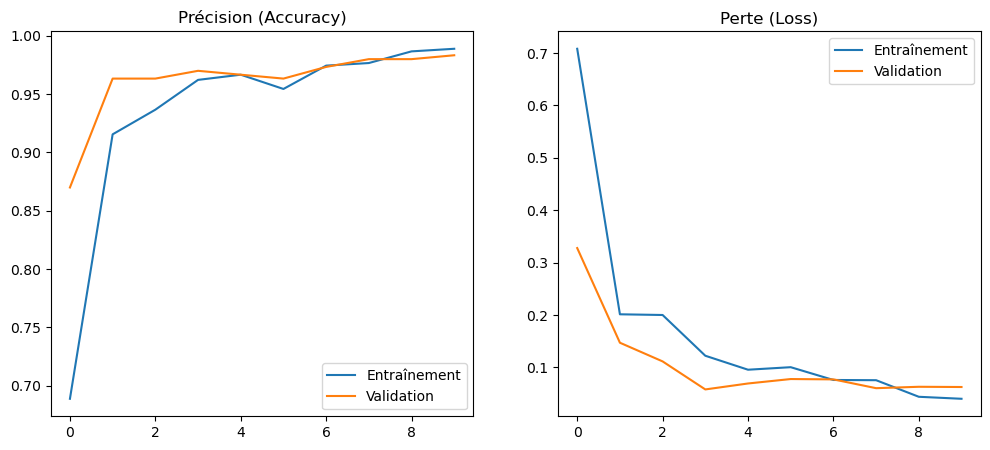

In [7]:
print("\n5. Affichage des résultats...")
# Récupération des données de l'historique
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

# Création du graphique
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement')
plt.plot(epochs_range, val_acc, label='Validation')
plt.legend(loc='lower right')
plt.title('Précision (Accuracy)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement')
plt.plot(epochs_range, val_loss, label='Validation')
plt.legend(loc='upper right')
plt.title('Perte (Loss)')
plt.show()

# ==============================================================================
# 6. CALCUL DU F1-SCORE
# ==============================================================================

In [8]:
y_true = []
y_pred_probs = []

for images, labels in val_dataset:
    y_true.extend(labels.numpy().flatten())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_pred = np.array([1 if p > 0.5 else 0 for p in y_pred_probs])

print("\n=== RAPPORT FINAL ===")
print(classification_report(y_true, y_pred, target_names=['Saine - 0', 'Malade - 1']))
print(f"F1-Score Global : {f1_score(y_true, y_pred):.4f}")


=== RAPPORT FINAL ===
              precision    recall  f1-score   support

   Saine - 0       0.95      1.00      0.98       100
  Malade - 1       1.00      0.97      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.99      0.98       300
weighted avg       0.98      0.98      0.98       300

F1-Score Global : 0.9873


# ==============================================================================
# 7. ÉVALUATION FINALE SUR LE DATASET DE TEST
# ==============================================================================

In [9]:
print("\n=== ÉVALUATION SUR LES DONNÉES DE TEST ===")

# 1. Définition du chemin vers le dossier Test binaire
test_dir = os.path.join(binary_dataset_dir, 'Test')

# 2. Chargement du dataset de Test
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, 
    image_size=IMAGE_SIZE, 
    batch_size=BATCH_SIZE, 
    label_mode='binary',
    shuffle=False # On ne mélange pas pour garder l'ordre des vraies étiquettes
)

# 3. Normalisation (Très important : appliquer la même transformation qu'à l'entraînement)
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# 4. Évaluation globale (Loss et Accuracy)
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f"\nPrécision (Accuracy) sur le Test : {test_acc*100:.2f}%")
print(f"Perte (Loss) sur le Test : {test_loss:.4f}")

# 5. Calcul détaillé du F1-Score sur le Test
y_true_test = []
y_pred_probs_test = []

for images, labels in test_dataset:
    y_true_test.extend(labels.numpy().flatten())
    preds = model.predict(images, verbose=0)
    y_pred_probs_test.extend(preds.flatten())

# Seuil de 0.5 pour la classification binaire
y_pred_test = np.array([1 if p > 0.5 else 0 for p in y_pred_probs_test])

print("\n=== RAPPORT DE CLASSIFICATION (TEST) ===")
print(classification_report(y_true_test, y_pred_test, target_names=['Saine - 0', 'Malade - 1']))
print(f"F1-Score Global (Test) : {f1_score(y_true_test, y_pred_test):.4f}")


=== ÉVALUATION SUR LES DONNÉES DE TEST ===
Found 1200 files belonging to 2 classes.
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7408 - loss: 2.1769

Précision (Accuracy) sur le Test : 74.08%
Perte (Loss) sur le Test : 2.1769

=== RAPPORT DE CLASSIFICATION (TEST) ===
              precision    recall  f1-score   support

   Saine - 0       0.24      1.00      0.39       100
  Malade - 1       1.00      0.72      0.84      1100

    accuracy                           0.74      1200
   macro avg       0.62      0.86      0.61      1200
weighted avg       0.94      0.74      0.80      1200

F1-Score Global (Test) : 0.8354


# ==============================================================================
# 8. PRÉDICTION SUR UNE NOUVELLE IMAGE (SIMULATION RÉELLE)
# ==============================================================================

In [10]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

#chemin_image = "Potato\Valid\Potato___Late_blight\84182903-22be-4563-8276-d72413958ada___RS_LB 4027.JPG"
def diagnostiquer_feuille(chemin_image, modele):
    """
    Prend le chemin d'une image, la prépare, et utilise le modèle pour 
    prédire si la feuille est saine ou malade.
    """
    print(f"Analyse en cours : {chemin_image}")
    
    # 1. Chargement et redimensionnement (Doit correspondre à IMAGE_SIZE)
    try:
        img = image.load_img(chemin_image, target_size=(256, 256))
    except FileNotFoundError:
        print("Erreur : L'image est introuvable. Vérifiez le chemin.")
        return
        
    # 2. Conversion en matrice de pixels
    img_array = image.img_to_array(img)
    
    # 3. Normalisation (Très important : appliquer la même division par 255 qu'à l'entraînement)
    img_array = img_array / 255.0
    
    # 4. Ajout de la dimension du "batch" -> Le modèle attend (batch_size, 256, 256, 3)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # 5. Prédiction avec le modèle
    prediction_prob = modele.predict(img_batch, verbose=0)[0][0]
    
    # 6. Interprétation du résultat (Seuil à 0.5 avec la fonction Sigmoïde)
    if prediction_prob > 0.5:
        diagnostic = "🚨 Feuille Malade (Classe 1)"
        confiance = prediction_prob * 100
    else:
        diagnostic = "✅ Feuille Saine (Classe 0)"
        confiance = (1 - prediction_prob) * 100
        
    # 7. Affichage visuel du résultat
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{diagnostic} - Confiance : {confiance:.2f}%")
    plt.show()
    
    print(f"-> Résultat final : {diagnostic}")
    print(f"-> Niveau de certitude du modèle : {confiance:.2f}%")

# --- EXEMPLE D'UTILISATION ---
# Copiez-collez le chemin relatif ou absolu d'une image de votre dossier Test
# Par exemple :
# image_a_tester = "./Potato/Test/Potato___Early_blight/une_image_au_hasard.jpg"
# diagnostiquer_feuille(image_a_tester, model)

Analyse en cours : Valid/Potato___Early_blight/af0ee942-50f5-43a7-a9fe-486ba1f5f989___RS_Early.B 7700.JPG


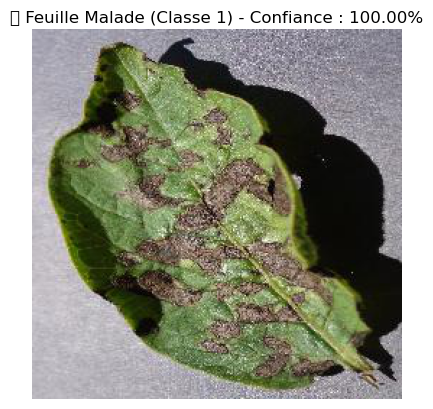

-> Résultat final : 🚨 Feuille Malade (Classe 1)
-> Niveau de certitude du modèle : 100.00%
Analyse en cours : Valid/Potato___Early_blight/af0ee942-50f5-43a7-a9fe-486ba1f5f989___RS_Early.B 7700.JPG


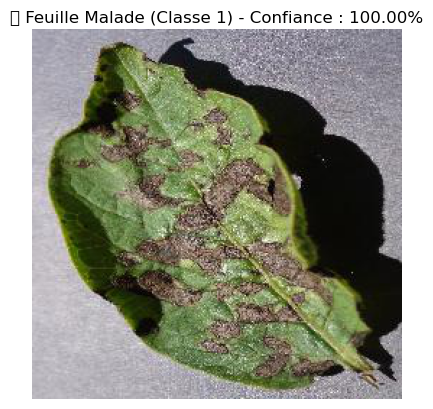

-> Résultat final : 🚨 Feuille Malade (Classe 1)
-> Niveau de certitude du modèle : 100.00%


In [22]:
# 1. Allez dans votre dossier "./Potato/Test/Potato___Early_blight" (ou un autre)
# 2. Copiez le nom exact d'une image qui s'y trouve
# 3. Mettez le chemin complet ici :

mon_image_test = "Valid/Potato___Early_blight/af0ee942-50f5-43a7-a9fe-486ba1f5f989___RS_Early.B 7700.JPG"

diagnostiquer_feuille(mon_image_test, model)

# 4. On lance l'analyse !
diagnostiquer_feuille(mon_image_test, model)

🚀 DÉMARRAGE DES EXPÉRIENCES...

--- Expérience 1 : Adam | LR = 0.001 | Avec Dropout ---
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step - accuracy: 0.6500 - loss: 0.8337 - val_accuracy: 0.6633 - val_loss: 0.4591
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.8889 - loss: 0.2676 - val_accuracy: 0.9567 - val_loss: 0.1422
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.9500 - loss: 0.1409 - val_accuracy: 0.9500 - val_loss: 0.1255
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9533 - loss: 0.1240 - val_accuracy: 0.9733 - val_loss: 0.0816
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - accuracy: 0.9722 - loss: 0.0678 - val_accuracy: 0.9733 - val_loss: 0.0621
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - accuracy: 0.9822 - loss: 0.0485 - val_accuracy: 0.6933 - val_loss: 0.8101
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step - accuracy: 0.8600 - loss: 0.3875 - val_accuracy: 0.9433 - val_loss: 0.1528
Epoch 8/15
29/29

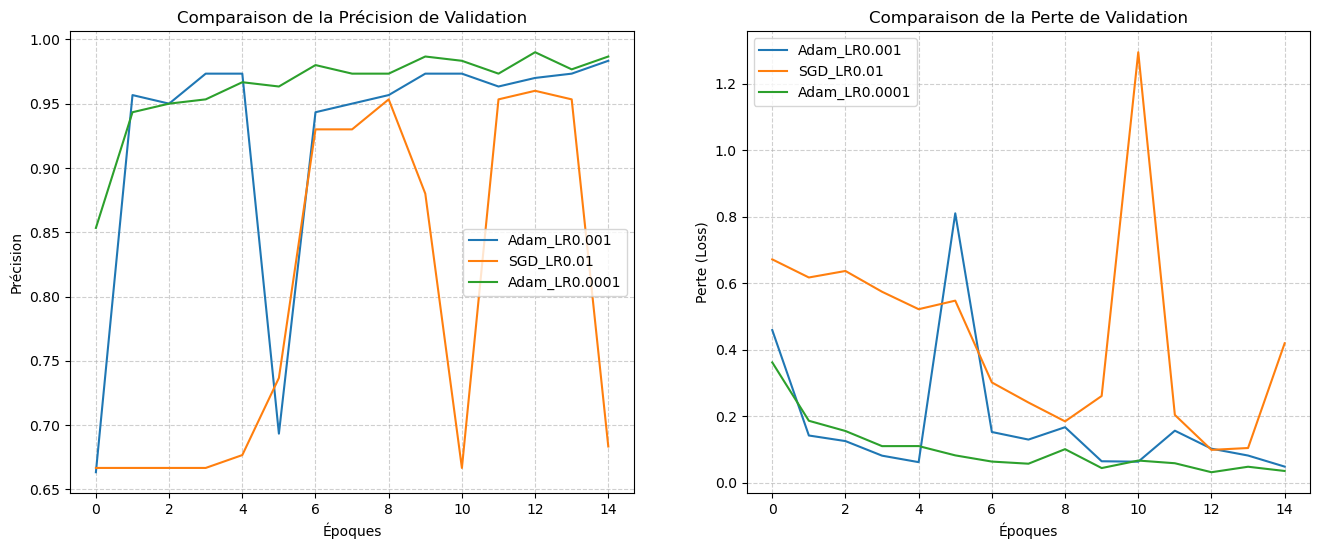

In [12]:
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

# ==============================================================================
# FONCTION POUR CRÉER DES MODÈLES SUR MESURE (POUR L'EXPÉRIMENTATION)
# ==============================================================================
def construire_modele(utilisation_dropout=True, optimiseur='adam', taux_apprentissage=0.001):
    """Construit et compile un modèle avec des hyperparamètres spécifiques."""
    model = models.Sequential([
        layers.Input(shape=(256, 256, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Ajout d'une couche supplémentaire (Point 1 de la consigne)
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu')
    ])
    
    # Utilisation du Dropout (Point 1 de la consigne)
    if utilisation_dropout:
        model.add(layers.Dropout(0.5)) 
        
    model.add(layers.Dense(1, activation='sigmoid'))

    # Choix de l'optimiseur et du taux d'apprentissage (Points 2 et 3 de la consigne)
    if optimiseur.lower() == 'adam':
        opt = optimizers.Adam(learning_rate=taux_apprentissage)
    elif optimiseur.lower() == 'sgd':
        opt = optimizers.SGD(learning_rate=taux_apprentissage)
        
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ==============================================================================
# LANCEMENT DES EXPÉRIENCES
# ==============================================================================
# Point 4 : On ajuste le nombre d'époques à 15 pour voir le comportement à long terme
EPOCHS = 15 
historiques = {}

print("🚀 DÉMARRAGE DES EXPÉRIENCES...\n")

# Expérience 1 : Notre base (Adam classique)
print("--- Expérience 1 : Adam | LR = 0.001 | Avec Dropout ---")
modele_1 = construire_modele(utilisation_dropout=True, optimiseur='adam', taux_apprentissage=0.001)
historiques['Adam_LR0.001'] = modele_1.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)

# Expérience 2 : Test avec SGD (Généralement plus lent à converger)
print("\n--- Expérience 2 : SGD | LR = 0.01 | Avec Dropout ---")
modele_2 = construire_modele(utilisation_dropout=True, optimiseur='sgd', taux_apprentissage=0.01)
historiques['SGD_LR0.01'] = modele_2.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)

# Expérience 3 : Test avec Adam mais un taux d'apprentissage plus faible
print("\n--- Expérience 3 : Adam | LR = 0.0001 (Faible) | Avec Dropout ---")
modele_3 = construire_modele(utilisation_dropout=True, optimiseur='adam', taux_apprentissage=0.0001)
historiques['Adam_LR0.0001'] = modele_3.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)

# ==============================================================================
# AFFICHAGE DE LA COMPARAISON VISUELLE (IDÉAL POUR LE RAPPORT)
# ==============================================================================
plt.figure(figsize=(16, 6))

# Graphique de Précision (Accuracy)
plt.subplot(1, 2, 1)
for nom, hist in historiques.items():
    plt.plot(hist.history['val_accuracy'], label=f'{nom}')
plt.title('Comparaison de la Précision de Validation')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Graphique de Perte (Loss)
plt.subplot(1, 2, 2)
for nom, hist in historiques.items():
    plt.plot(hist.history['val_loss'], label=f'{nom}')
plt.title('Comparaison de la Perte de Validation')
plt.xlabel('Époques')
plt.ylabel('Perte (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

✅ Le meilleur modèle a été sauvegardé avec succès sous : meilleur_modele_maladie.keras

--- Analyse en cours : Valid/Potato___Early_blight/72013507-bfce-4b7a-b56e-f66a94cb4558___RS_Early.B 7930.JPG ---


c:\Users\nzigu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


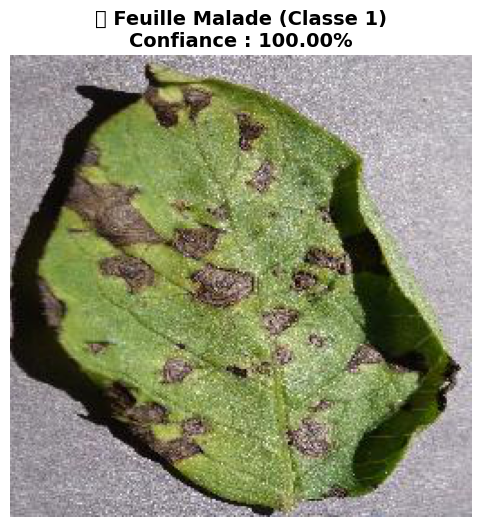

-> Résultat de l'IA : 🚨 Feuille Malade (Classe 1)
-> Niveau de certitude : 100.00%


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. SAUVEGARDE DU MEILLEUR MODÈLE (Adam, LR=0.001)
# ==============================================================================
# "modele_1" est la variable qui contient notre meilleure expérience (cellule précédente)
chemin_sauvegarde = 'meilleur_modele_maladie.keras'
modele_1.save(chemin_sauvegarde)
print(f"✅ Le meilleur modèle a été sauvegardé avec succès sous : {chemin_sauvegarde}")

# ==============================================================================
# 2. FONCTION FINALE DE DIAGNOSTIC
# ==============================================================================
def diagnostiquer_feuille_finale(chemin_image):
    """
    Charge la meilleure IA sauvegardée et analyse une nouvelle image.
    """
    print(f"\n--- Analyse en cours : {chemin_image} ---")
    
    # 1. Chargement du modèle depuis le disque dur
    try:
        modele = load_model(chemin_sauvegarde)
    except Exception as e:
        print(f"Erreur lors du chargement du modèle : {e}")
        return

    # 2. Chargement et préparation de l'image
    try:
        img = image.load_img(chemin_image, target_size=(256, 256))
    except FileNotFoundError:
        print("Erreur : L'image est introuvable. Vérifiez le chemin d'accès (utilisez r\"...\").")
        return
        
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Normalisation (Identique à l'entraînement)
    img_batch = np.expand_dims(img_array, axis=0) # Ajout de la dimension "batch"
    
    # 3. Prédiction
    probabilite = modele.predict(img_batch, verbose=0)[0][0]
    
    # 4. Interprétation (Seuil de décision à 0.5)
    if probabilite > 0.5:
        diagnostic = "🚨 Feuille Malade (Classe 1)"
        confiance = probabilite * 100
    else:
        diagnostic = "✅ Feuille Saine (Classe 0)"
        confiance = (1 - probabilite) * 100
        
    # 5. Affichage visuel
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{diagnostic}\nConfiance : {confiance:.2f}%", fontsize=14, fontweight='bold')
    plt.show()
    
    print(f"-> Résultat de l'IA : {diagnostic}")
    print(f"-> Niveau de certitude : {confiance:.2f}%")

# ==============================================================================
# 3. EXÉCUTION DU TEST
# ==============================================================================
# Test avec votre image (n'oubliez pas le 'r' devant le chemin sous Windows)
chemin_test = "Valid/Potato___Early_blight/72013507-bfce-4b7a-b56e-f66a94cb4558___RS_Early.B 7930.JPG" 

diagnostiquer_feuille_finale(chemin_test)